# **EQUIPO LFM** | Aprendizaje automatico

## Bibliotecas a utilizar en el cuaderno

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

Creación de un dataframe a partir del archivo csv

In [ ]:
dfIris = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vSLgU6YF5djPgcJvcmXyqdIjfVefPsYlj6HUnRH15sZwsEL4GX7KPY-c3CWgM3n8vCljid-ZPocdAAl/pub?output=csv')

## Preprocesamiento

### Feature Scaling
- No se hace uso de un StandardScaler o MinMaxScaler para unificar las escalas porque en el dataset estas ya estan informadas en la misma escala (centímetros).

### Header standarization & data cleaning

- Renombraremos las columnas al español, y eliminaremos la columan Id ya que no será utilizada para el análisis

In [ ]:
#Renombrado de columnas
dfIris.rename({'SepalLengthCm':'sepalo_largo',
           'SepalWidthCm':'sepalo_ancho',
           'PetalLengthCm':'petalo_largo',
           'PetalWidthCm':'petalo_ancho',
           'Species':'especies'},
          axis=1, inplace=True) # inplace = True para que el renombrado sea sobre el mismo df

dfIris.drop('Id', axis=1, inplace=True) #axis=1 indica que es una columna

Inspección de la forma del df

In [ ]:
dfIris.shape

(150, 5)

Visualización del segmento inicial y final de los datos

In [ ]:
dfIris

,sepalo_largo,sepalo_ancho,petalo_largo,petalo_ancho,especies
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
X = dfIris.drop(['petalo_ancho', 'especies'], axis=1)
y = dfIris['petalo_ancho']

### Matriz de Correlación

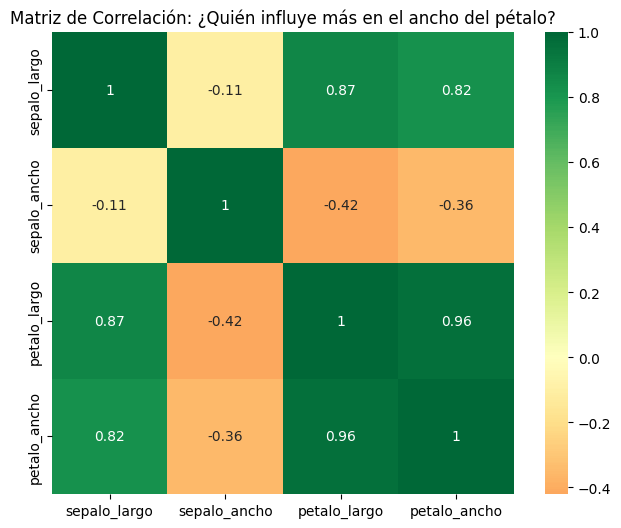

In [ ]:
# 1. Calculamos la correlación de las columnas numéricas
matriz_corr = dfIris.drop(columns=['especies']).corr()

# 2. Generamos el gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='RdYlGn', center=0, square=True)

plt.title('Matriz de Correlación: ¿Quién influye más en el ancho del pétalo?')
plt.show()

## Particionamiento

In [ ]:
# 2. División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Optimización

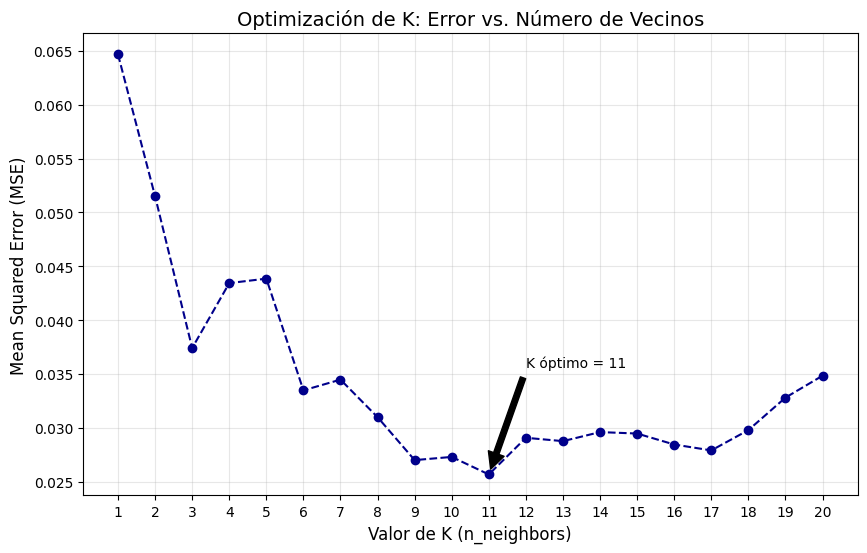

In [ ]:
k_values = range(1, 21) # Probamos k desde 1 hasta 20
errores_mse = []

for k in k_values:
    # Entrenar modelo con el k actual
    modelo = KNeighborsRegressor(n_neighbors=k)
    modelo.fit(X_train, y_train)

    # Predecir y calcular el error
    predicciones = modelo.fit(X_train, y_train).predict(X_test)
    mse = mean_squared_error(y_test, predicciones)
    errores_mse.append(mse)

# Guardar resultados y graficar
resultados = pd.DataFrame({'k': k_values, 'MSE': errores_mse})

plt.figure(figsize=(10, 6))
plt.plot(k_values, errores_mse, marker='o', linestyle='--', color='darkblue')

# Estética del gráfico
plt.title('Optimización de K: Error vs. Número de Vecinos', fontsize=14)
plt.xlabel('Valor de K (n_neighbors)', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.xticks(k_values) # Para ver todos los números del 1 al 20
plt.grid(True, alpha=0.3)

# Marcar el punto óptimo
min_mse = min(errores_mse)
best_k = k_values[errores_mse.index(min_mse)]
plt.annotate(f'K óptimo = {best_k}',
             xy=(best_k, min_mse),
             xytext=(best_k + 1, min_mse + 0.01),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

## Implementación de KNN Regresor

In [ ]:
knn = KNeighborsRegressor(n_neighbors=11)
knn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=11)

## Predicciones

In [ ]:
y_pred = knn.predict(X_test)

## Evaluación

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Resultados KNN:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Resultados KNN:
Mean Squared Error: 0.0257
R² Score: 0.9596


## Visualización de los resultados

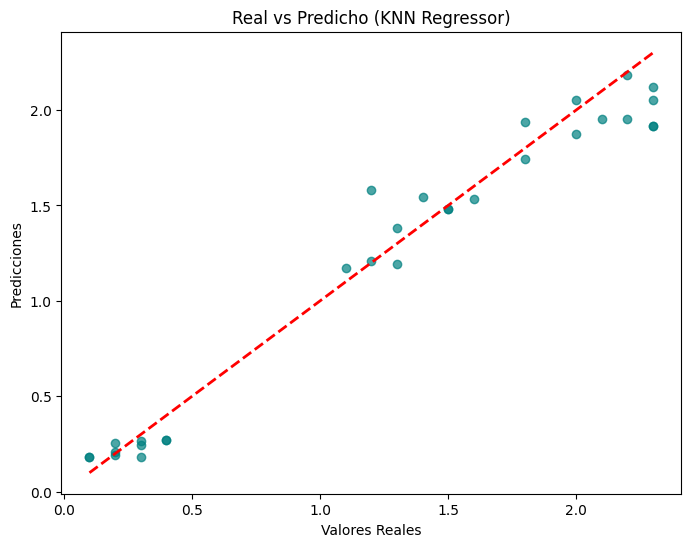

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Real vs Predicho (KNN Regressor)')
plt.show()

### Reducción de dimensionalidad
Sin pétalo largo ni sepalo largo

In [ ]:
X = dfIris.drop(['petalo_ancho', 'especies', 'sepalo_largo'], axis=1)
y = dfIris['petalo_ancho']

In [ ]:
# 2. División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
knn = KNeighborsRegressor(n_neighbors=11)
knn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=11)

In [ ]:
y_pred = knn.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Resultados KNN:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Resultados KNN:
Mean Squared Error: 0.0313
R² Score: 0.9507


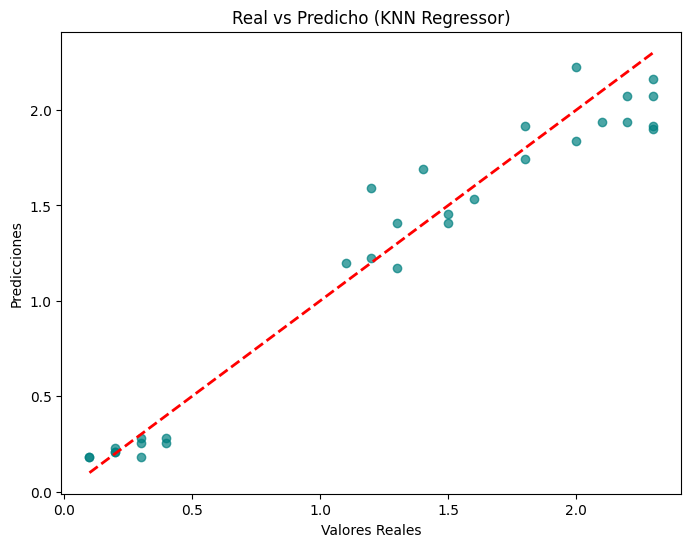

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.title('Real vs Predicho (KNN Regressor)')
plt.show()

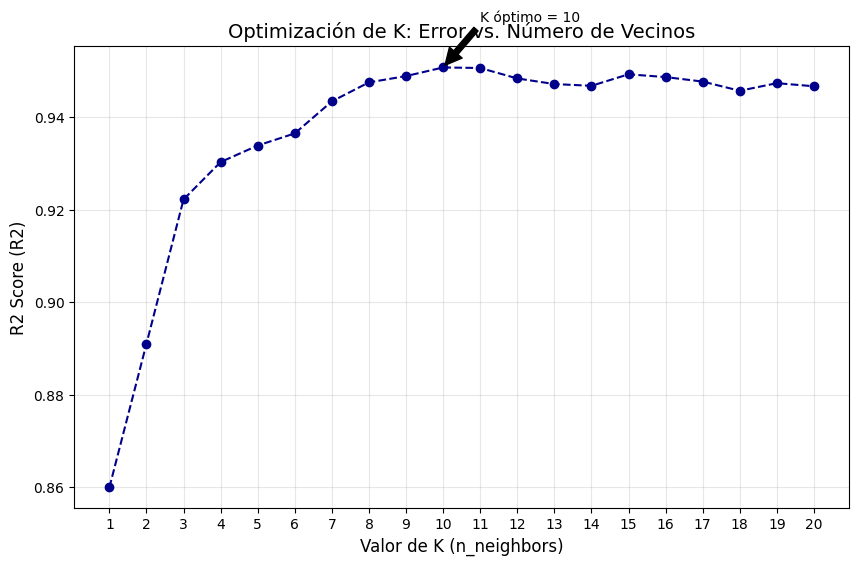

In [ ]:
k_values = range(1, 21) # Probamos k desde 1 hasta 20
errores_r2 = []

for k in k_values:
    # Entrenar modelo con el k actual
    modelo = KNeighborsRegressor(n_neighbors=k)
    modelo.fit(X_train, y_train)

    # Predecir y calcular el error
    predicciones = modelo.fit(X_train, y_train).predict(X_test)
    r2 = r2_score(y_test, predicciones)
    errores_r2.append(r2)

# Guardar resultados y graficar
resultados = pd.DataFrame({'k': k_values, 'MSE': errores_r2})

plt.figure(figsize=(10, 6))
plt.plot(k_values, errores_r2, marker='o', linestyle='--', color='darkblue')

# Estética del gráfico
plt.title('Optimización de K: Error vs. Número de Vecinos', fontsize=14)
plt.xlabel('Valor de K (n_neighbors)', fontsize=12)
plt.ylabel('R2 Score (R2)', fontsize=12)
plt.xticks(k_values) # Para ver todos los números del 1 al 20
plt.grid(True, alpha=0.3)

# Marcar el punto óptimo
max_r2 = max(errores_r2)
best_k = k_values[errores_r2.index(max_r2)]
plt.annotate(f'K óptimo = {best_k}',
             xy=(best_k, max_r2),
             xytext=(best_k + 1, max_r2 + 0.01),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()